In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import optuna
from xgboost import XGBClassifier
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.combine import  SMOTEENN, SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter


In [10]:
cyclists_data = pd.read_csv("dataset/cyclists.csv",index_col=0)
races_data = pd.read_csv("dataset/races.csv",index_col=0)
cyclists_data.info()
cyclists_data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 6134 entries, 0 to 6133
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         6134 non-null   object 
 1   birth_year   6121 non-null   float64
 2   weight       3078 non-null   float64
 3   height       3143 non-null   float64
 4   nationality  6133 non-null   object 
 5   cyclist_id   6134 non-null   object 
dtypes: float64(3), object(3)
memory usage: 335.5+ KB


,name,birth_year,weight,height,nationality,cyclist_id
0,Bruno Surra,1964.0,NaN,NaN,Italy,bruno-surra
1,Gérard Rué,1965.0,74.0,182.0,France,gerard-rue
2,Jan Maas,1996.0,69.0,189.0,Netherlands,jan-maas
3,Nathan Van Hooydonck,1995.0,78.0,192.0,Belgium,nathan-van-hooydonck
4,José Félix Parra,1997.0,55.0,171.0,Spain,jose-felix-parra


In [11]:
races_data.info()
races_data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 589865 entries, 0 to 589864
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   _url                 589865 non-null  object 
 1   name                 589865 non-null  object 
 2   points               589388 non-null  float64
 3   uci_points           251086 non-null  float64
 4   length               589865 non-null  float64
 5   climb_total          442820 non-null  float64
 6   profile              441671 non-null  float64
 7   startlist_quality    589865 non-null  int64  
 8   average_temperature  29933 non-null   float64
 9   date                 589865 non-null  object 
 10  position             589865 non-null  int64  
 11  cyclist_age          589752 non-null  float64
 12  is_tarmac            589865 non-null  bool   
 13  is_cobbled           589865 non-null  bool   
 14  is_gravel            589865 non-null  bool   
 15  cyclist_team         4

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,position,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta,cyclist_id
0,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,0,22.0,True,False,False,vini-ricordi-pinarello-sidermec-1986,0.0,sean-kelly
1,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,1,27.0,True,False,False,norway-1987,0.0,gerrie-knetemann
2,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,2,24.0,True,False,False,NaN,0.0,rene-bittinger
3,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,3,30.0,True,False,False,navigare-blue-storm-1993,0.0,joseph-bruyere
4,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,4,27.0,True,False,False,spain-1991,0.0,sven-ake-nilsson


# 1. Data Processing

## 1.1 Categorical variables,  normalizing and standarizing

In [ ]:
# Define function to categorize 'position'
# This will later be the label for our classifiers
def categorize_position(pos):
    if pos <= 3:
        return "Podium"
    elif pos <= 20:
        return "Top20"
    elif pos <= 50:
        return "Top50"
    elif pos <= 100:
        return "Top100"
    else:
        return "Remaining"

# Apply categorization
races_data["position_category"] = races_data["position"].apply(categorize_position)


races_data = races_data.drop("position", axis=1)

# Check distribution of categories
position_distribution = races_data["position_category"].value_counts(normalize=True) * 100

position_distribution


,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta,cyclist_id,position_category
0,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,22.0,True,False,False,vini-ricordi-pinarello-sidermec-1986,0.0,sean-kelly,Podium
1,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,27.0,True,False,False,norway-1987,0.0,gerrie-knetemann,Podium
2,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,24.0,True,False,False,NaN,0.0,rene-bittinger,Podium
3,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,30.0,True,False,False,navigare-blue-storm-1993,0.0,joseph-bruyere,Podium
4,tour-de-france/1978/stage-6,Tour de France,100.0,NaN,162000.0,1101.0,1.0,1241,NaN,1978-07-05 04:02:24,27.0,True,False,False,spain-1991,0.0,sven-ake-nilsson,Top20


In [16]:
# Identify float64 columns
float_cols = races_data.select_dtypes(include=['float64']).columns

# Convert float64 to int, handling NaN values
for col in float_cols:
    if col in ['points', 'climb_total', 'uci_points', 'length', 'cyclist_age', 'delta']:  # Specify columns that should be int
        races_data[col] = races_data[col].fillna(0).astype(int)  # Replace NaN with 0 before conversion

# Check the new data types
print(races_data.dtypes)

_url                    object
name                    object
points                   int32
uci_points               int32
length                   int32
climb_total              int32
profile                float64
startlist_quality        int64
average_temperature    float64
date                    object
cyclist_age              int32
is_tarmac                 bool
is_cobbled                bool
is_gravel                 bool
cyclist_team            object
delta                    int32
cyclist_id              object
position_category       object
dtype: object


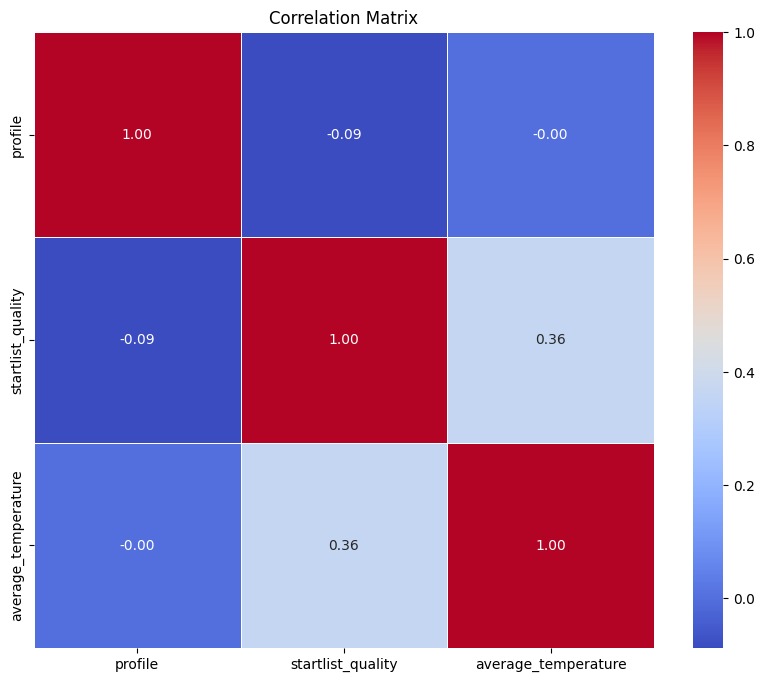

In [17]:
numerical_cols = races_data.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix for numerical columns
correlation_matrix = numerical_cols.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))  # Adjust the size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Title and show the plot
plt.title("Correlation Matrix")
plt.show()

In [18]:
# Nationality from object to category
cyclists_data['nationality'] = cyclists_data['nationality'].astype('category')

# Convert the 'cyclist_team' column to category type
races_data['cyclist_team'] = races_data['cyclist_team'].astype('category')
# Convert the 'cyclists_age' column to int32 type
races_data['cyclist_age'] = races_data['cyclist_age'].astype('int32')

# Correcting some type castings that are unnecesary in races dataset
races_data['points'] = races_data['points'].astype(int)
races_data['length'] = races_data['length'].astype(int)
races_data['delta'] = races_data['delta'].astype(int)
races_data['cyclist_age'] = races_data['cyclist_age'].astype(int)
races_data['cyclist_id'] = races_data['cyclist_id'].astype('string')

# Split _url into into ['race_name', 'year', 'stage'] by /
races_data[['race_name', 'year', 'stage']] = races_data['_url'].str.split('/', expand=True)
races_data = races_data.drop(columns=['_url'])
#races_data['stage'] = races_data['stage'].astype('string')
races_data['year'] = races_data['year'].astype(int)

# Now we have 2 columns with race_name
races_data = races_data.drop(columns=['name'])

# Extract month from date and remove date
# Year already from _url and we discard day and hour
races_data['date'] = pd.to_datetime(races_data['date'])
races_data['month'] = races_data['date'].dt.month
races_data = races_data.drop(columns=['date'])

# climb_total and profile are highly correlated, so we combine them
races_data['aug_profile'] = np.where(
    races_data['climb_total'].notna() & races_data['profile'].notna(),
    races_data['climb_total'] / races_data['climb_total'].max() + races_data['profile'],
    np.nan  # Assign NaN if either column is still missing
)
races_data = races_data.drop(columns=['climb_total'])
races_data = races_data.drop(columns=['profile'])

In [19]:
# Encode categorical values of races df
categorical_cols = ['cyclist_team', 'race_name', 'stage']
encoder = LabelEncoder()

for col in categorical_cols:
    races_data[col] = encoder.fit_transform(races_data[col])
    
cyclists_data['nationality'] = encoder.fit_transform(cyclists_data['nationality'])

In [20]:
# Always: is_tarmac= true, is_cobbled=False, is_gravel=False
races_data = races_data.drop(columns=['is_tarmac', 'is_cobbled', 'is_gravel'])

## 1.2 Managing missing values

In [21]:
cyclists_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6134 entries, 0 to 6133
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         6134 non-null   object 
 1   birth_year   6121 non-null   float64
 2   weight       3078 non-null   float64
 3   height       3143 non-null   float64
 4   nationality  6134 non-null   int32  
 5   cyclist_id   6134 non-null   object 
dtypes: float64(3), int32(1), object(2)
memory usage: 311.5+ KB


In [22]:
# We dont need name with id
cyclists_data = cyclists_data.drop(columns=['name'])
# as we have cyclists_age in races, this dooes not have any mean (-1 correlation for sure)
cyclists_data = cyclists_data.drop(columns=['birth_year'])

In [23]:
# Checkimg (and removing if there were any) duplicates in both datasets
duplicated_races = races_data[races_data.duplicated(keep=False)]
print(duplicated_races.shape)

duplicated_cyclists = cyclists_data[cyclists_data.duplicated(keep=False)]
print(duplicated_cyclists.shape)

(44, 15)
(0, 4)


In [24]:
print(cyclists_data.shape)
print("Number of null in cyclists dataset")
print("----------------------------------")
print(cyclists_data.isnull().sum(),'\n')

print("Percentage of null in cyclists dataset")
print("----------------------------------")
print(round(cyclists_data.isnull().sum()*100/cyclists_data.shape[0],2).astype(str) + '%')

(6134, 4)
Number of null in cyclists dataset
----------------------------------
weight         3056
height         2991
nationality       0
cyclist_id        0
dtype: int64 

Percentage of null in cyclists dataset
----------------------------------
weight         49.82%
height         48.76%
nationality      0.0%
cyclist_id       0.0%
dtype: object


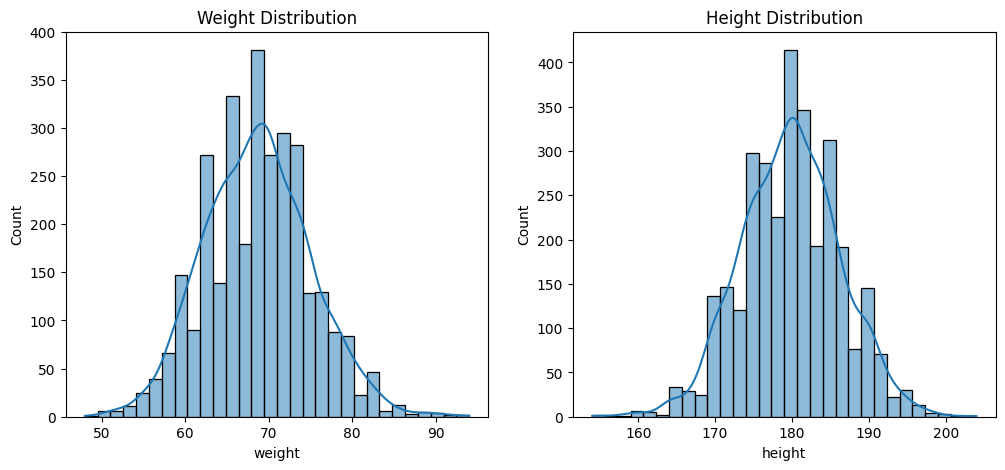

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(cyclists_data['weight'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Weight Distribution')

sns.histplot(cyclists_data['height'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Height Distribution')

plt.show()

In [26]:
cyclists_data_imp_mean = cyclists_data.copy()

cyclists_data_imp_mean['height_missing'] = np.where(cyclists_data_imp_mean['height'].isna(), 1, 0)
cyclists_data_imp_mean['weight_missing'] = np.where(cyclists_data_imp_mean['weight'].isna(), 1, 0)

cyclists_data_imp_mean['weight'].fillna(cyclists_data_imp_mean['weight'].mean(), inplace=True)
cyclists_data_imp_mean['height'].fillna(cyclists_data_imp_mean['height'].mean(), inplace=True)

# cyclists_data_imp_median = cyclists_data.copy()
# cyclists_data_imp_median['birth_year'].fillna(cyclists_data_imp_median['birth_year'].mean(), inplace=True)
# cyclists_data_imp_median['weight'].fillna(cyclists_data_imp_median['weight'].mean(), inplace=True)
# cyclists_data_imp_median['height'].fillna(cyclists_data_imp_median['height'].mean(), inplace=True)

C:\Users\maria\AppData\Local\Temp\ipykernel_1712\3377930071.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cyclists_data_imp_mean['weight'].fillna(cyclists_data_imp_mean['weight'].mean(), inplace=True)
C:\Users\maria\AppData\Local\Temp\ipykernel_1712\3377930071.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setti

In [27]:
print("Correlation between columns")
print("----------------------------------")
print('Weight-Height\t',cyclists_data['weight'].corr(cyclists_data['height']))

Correlation between columns
----------------------------------
Weight-Height	 0.7207320842827667


In [20]:
# from sklearn.experimental import enable_iterative_imputer
# from sklearn.impute import IterativeImputer
# imp_iter = IterativeImputer(random_state=0)
# cyclists_data_name, cyclists_data_no_name = cyclists_data.iloc[:,-1:], cyclists_data.iloc[:,:-1]
# cyclists_data_no_name = pd.DataFrame(imp_iter.fit_transform(cyclists_data_no_name),columns=cyclists_data_no_name.columns)
# cyclists_data_no_name['cyclist_id'] = cyclists_data_name
# cyclists_data_imp_iter = cyclists_data_no_name.copy()
# cyclists_data_imp_iter

In [28]:
cyclists_data

,weight,height,nationality,cyclist_id
0,NaN,NaN,34,bruno-surra
1,74.0,182.0,24,gerard-rue
2,69.0,189.0,46,jan-maas
3,78.0,192.0,7,nathan-van-hooydonck
4,55.0,171.0,60,jose-felix-parra
...,...,...,...,...
6129,NaN,NaN,60,juan-jose-martinez-diaz
6130,75.0,188.0,60,inigo-elosegui
6131,NaN,NaN,34,paolo-alberati
6132,58.0,170.0,69,jackson-rodriguez


In [29]:
cyclists_data_imp_mean

,weight,height,nationality,cyclist_id,height_missing,weight_missing
0,68.658739,179.815145,34,bruno-surra,1,1
1,74.000000,182.000000,24,gerard-rue,0,0
2,69.000000,189.000000,46,jan-maas,0,0
3,78.000000,192.000000,7,nathan-van-hooydonck,0,0
4,55.000000,171.000000,60,jose-felix-parra,0,0
...,...,...,...,...,...,...
6129,68.658739,179.815145,60,juan-jose-martinez-diaz,1,1
6130,75.000000,188.000000,60,inigo-elosegui,0,0
6131,68.658739,179.815145,34,paolo-alberati,1,1
6132,58.000000,170.000000,69,jackson-rodriguez,0,0


In [30]:
races_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 589865 entries, 0 to 589864
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   points               589865 non-null  int32  
 1   uci_points           589865 non-null  int32  
 2   length               589865 non-null  int32  
 3   startlist_quality    589865 non-null  int64  
 4   average_temperature  29933 non-null   float64
 5   cyclist_age          589865 non-null  int32  
 6   cyclist_team         589865 non-null  int32  
 7   delta                589865 non-null  int32  
 8   cyclist_id           589865 non-null  string 
 9   position_category    589865 non-null  object 
 10  race_name            589865 non-null  int32  
 11  year                 589865 non-null  int32  
 12  stage                589865 non-null  int32  
 13  month                589865 non-null  int32  
 14  aug_profile          441671 non-null  float64
dtypes: float64(2), int32(1

In [31]:
print(races_data.shape)
print("Number of null in races dataset")
print("----------------------------------")
print(races_data.isnull().sum(),'\n')

print("Percentage of null in races dataset")
print("----------------------------------")
print(round(races_data.isnull().sum()*100/races_data.shape[0],2).astype(str) + '%')

(589865, 15)
Number of null in races dataset
----------------------------------
points                      0
uci_points                  0
length                      0
startlist_quality           0
average_temperature    559932
cyclist_age                 0
cyclist_team                0
delta                       0
cyclist_id                  0
position_category           0
race_name                   0
year                        0
stage                       0
month                       0
aug_profile            148194
dtype: int64 

Percentage of null in races dataset
----------------------------------
points                   0.0%
uci_points               0.0%
length                   0.0%
startlist_quality        0.0%
average_temperature    94.93%
cyclist_age              0.0%
cyclist_team             0.0%
delta                    0.0%
cyclist_id               0.0%
position_category        0.0%
race_name                0.0%
year                     0.0%
stage                   

In [32]:
# It has almost 100% of data loss, so we decided to drop it
races_data = races_data.drop(columns=['average_temperature'])

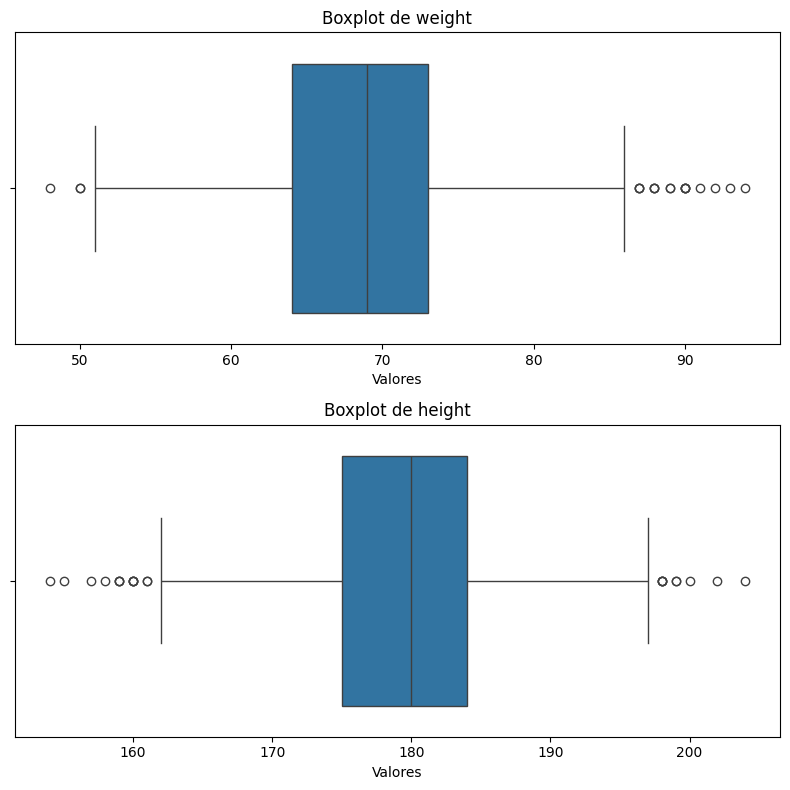

In [33]:
# Checking the columns on the cyclists dataset with the most null values
columns_to_plot = ['weight', 'height']

num_columns = len(columns_to_plot)
fig, axes = plt.subplots(num_columns, 1, figsize=(8, num_columns * 4))

for i, column in enumerate(columns_to_plot):
    sns.boxplot(data=cyclists_data, x=column, ax=axes[i])
    axes[i].set_title(f'Boxplot de {column}')
    axes[i].set_xlabel('Valores')

plt.tight_layout() 
plt.show()

In [34]:
races_data = races_data.rename(columns={"name": "race_name"})

merged_data = races_data.merge(cyclists_data_imp_mean, on="cyclist_id", how="left")

#it was necessary for the merge but is not for the model training
merged_data = merged_data.drop(columns=['cyclist_id'])

# Mostrar las primeras filas para verificar
print(merged_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589865 entries, 0 to 589864
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   points             589865 non-null  int32  
 1   uci_points         589865 non-null  int32  
 2   length             589865 non-null  int32  
 3   startlist_quality  589865 non-null  int64  
 4   cyclist_age        589865 non-null  int32  
 5   cyclist_team       589865 non-null  int32  
 6   delta              589865 non-null  int32  
 7   position_category  589865 non-null  object 
 8   race_name          589865 non-null  int32  
 9   year               589865 non-null  int32  
 10  stage              589865 non-null  int32  
 11  month              589865 non-null  int32  
 12  aug_profile        441671 non-null  float64
 13  weight             589865 non-null  float64
 14  height             589865 non-null  float64
 15  nationality        589865 non-null  int32  
 16  he

In [35]:
n_filas = len(merged_data)  # Número total de filas
filas_a_eliminar = int(n_filas * 0.70)  # La mitad (70%)

# Selecciona una muestra aleatoria del 70% de las filas para eliminar
filas_aleatorias = merged_data.sample(n=filas_a_eliminar, random_state=42).index

# Elimina esas filas del DataFrame
merged_data = merged_data.drop(filas_aleatorias)

print(f"DataFrame original: {len(merged_data)} filas")

DataFrame original: 176960 filas


In [36]:
merged_data.head()

,points,uci_points,length,startlist_quality,cyclist_age,cyclist_team,delta,position_category,race_name,year,stage,month,aug_profile,weight,height,nationality,height_missing,weight_missing
1,100,0,162000,1241,27,59,0,Podium,20,1978,44,7,1.157872,68.658739,179.815145,46,1,1
3,100,0,162000,1241,30,55,0,Podium,20,1978,44,7,1.157872,68.658739,179.815145,7,1,1
5,100,0,162000,1241,30,43,27,Top20,20,1978,44,7,1.157872,68.658739,179.815145,24,1,1
8,100,0,162000,1241,26,91,27,Top20,20,1978,44,7,1.157872,68.658739,179.815145,24,1,1
9,100,0,162000,1241,27,91,27,Top20,20,1978,44,7,1.157872,63.000000,164.000000,24,0,0


<Axes: >

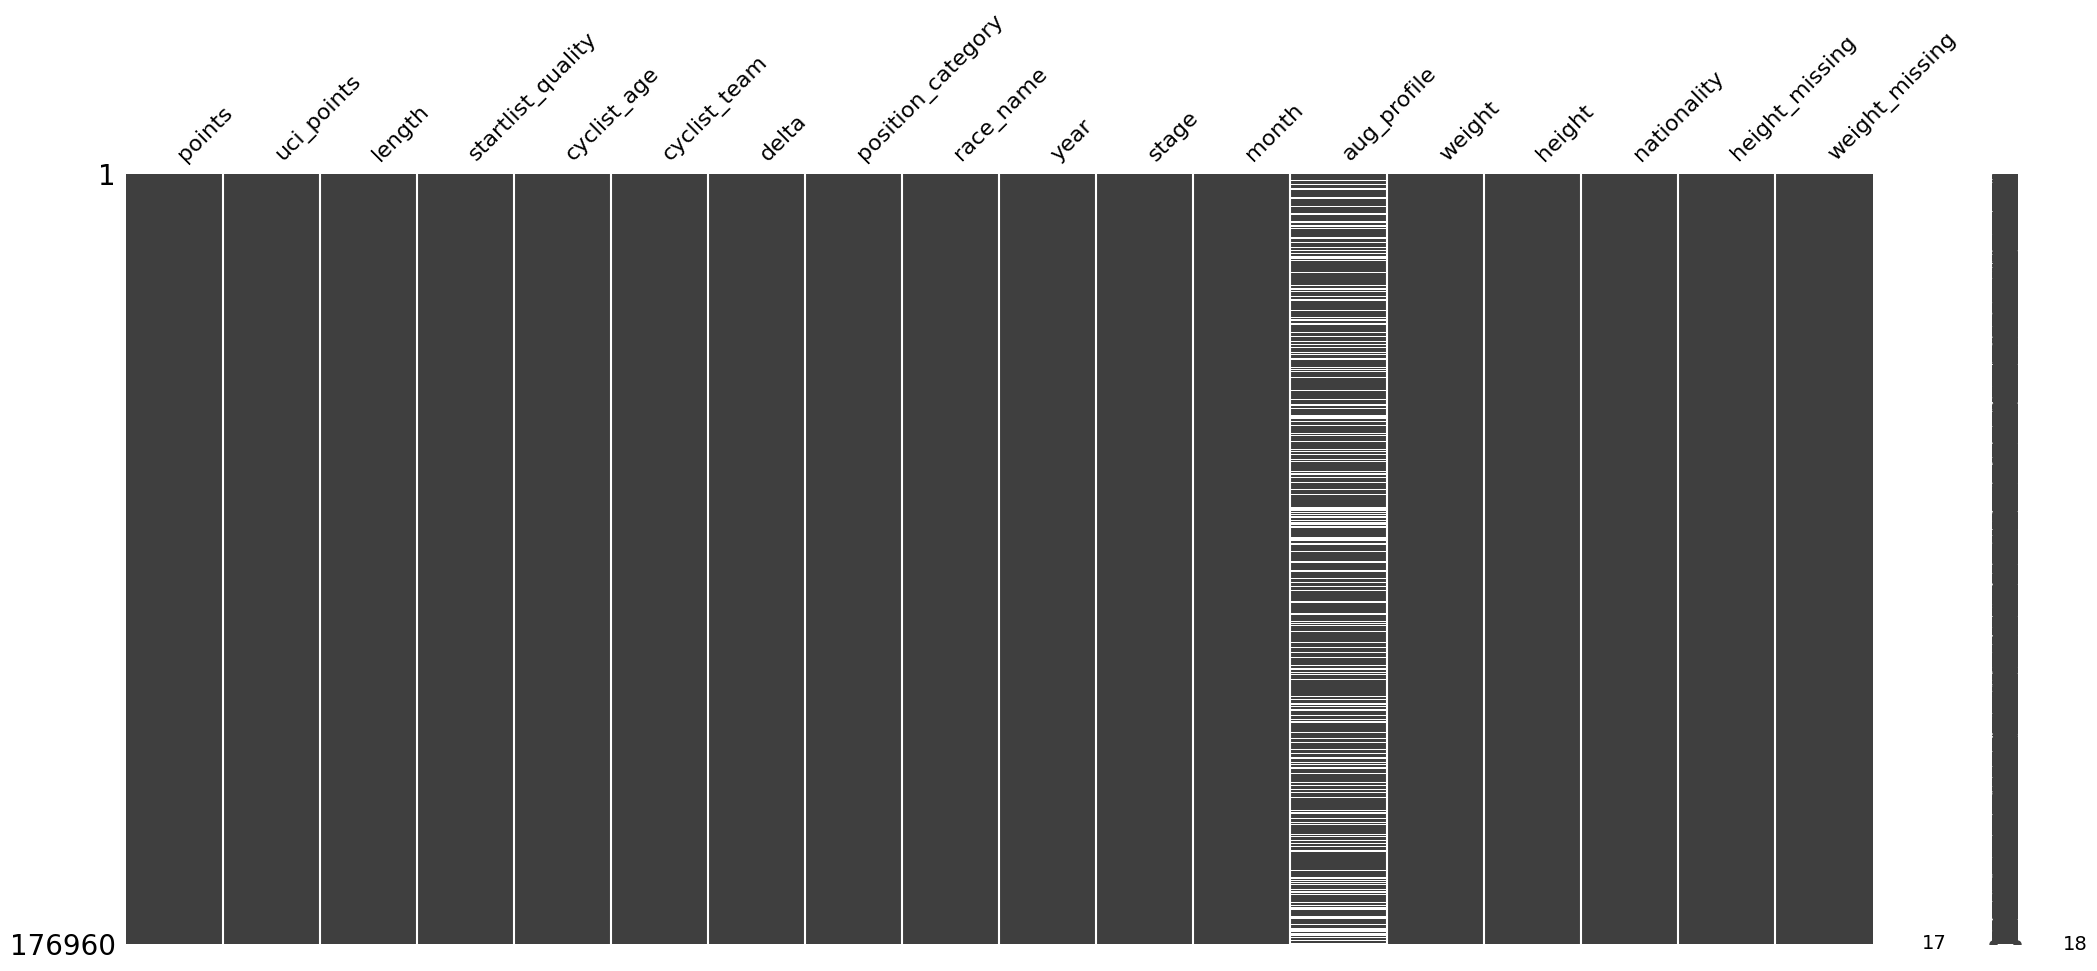

In [37]:
msno.matrix(merged_data)

In [38]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Encodear 'position_category'
merged_data['position_category'] = label_encoder.fit_transform(merged_data['position_category'])

merged_data.head()

,points,uci_points,length,startlist_quality,cyclist_age,cyclist_team,delta,position_category,race_name,year,stage,month,aug_profile,weight,height,nationality,height_missing,weight_missing
1,100,0,162000,1241,27,59,0,0,20,1978,44,7,1.157872,68.658739,179.815145,46,1,1
3,100,0,162000,1241,30,55,0,0,20,1978,44,7,1.157872,68.658739,179.815145,7,1,1
5,100,0,162000,1241,30,43,27,3,20,1978,44,7,1.157872,68.658739,179.815145,24,1,1
8,100,0,162000,1241,26,91,27,3,20,1978,44,7,1.157872,68.658739,179.815145,24,1,1
9,100,0,162000,1241,27,91,27,3,20,1978,44,7,1.157872,63.000000,164.000000,24,0,0


In [39]:
# Primero, dividimos el dataset en Train (70%)
train_data, temp_data = train_test_split(merged_data, test_size=0.30, random_state=42)

# Luego en Validation (15%) y Test (15%)
val_data, test_data = train_test_split(temp_data, test_size=0.50, random_state=42)

# Verificamos los tamaños de los conjuntos
print(f"Train set: {len(train_data)} muestras")
print(f"Validation set: {len(val_data)} muestras")
print(f"Test set: {len(test_data)} muestras")

Train set: 123872 muestras
Validation set: 26544 muestras
Test set: 26544 muestras


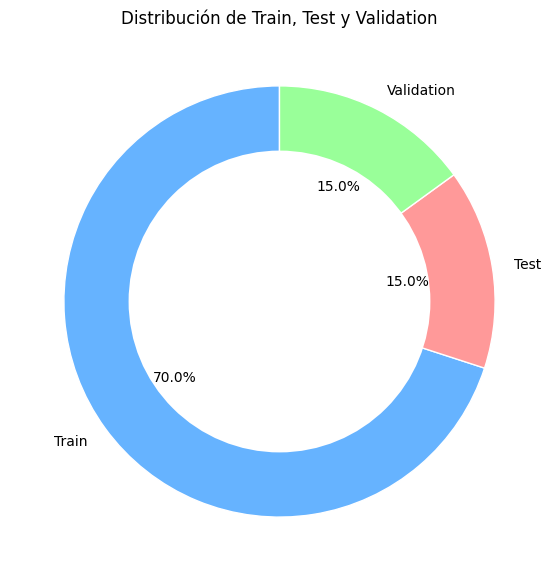

In [40]:
test_percentage = (test_data.shape[0] / merged_data.shape[0]) * 100
val_percentage = (val_data.shape[0] / merged_data.shape[0]) * 100
train_percentage = (train_data.shape[0] / merged_data.shape[0]) * 100

# Verificamos los tamaños de los conjuntos
labels = ['Train', 'Test', 'Validation']
sizes = [train_percentage, test_percentage, val_percentage]
colors = ['#66b3ff', '#ff9999', '#99ff99']  # Colores para cada segmento

# Crear la figura y el gráfico de dona
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'})

# Agregar un círculo en el centro para convertirlo en donut
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Título
plt.title("Distribución de Train, Test y Validation")
plt.show()

In [42]:
# Columnas que NO quieres estandarizar
non_scale_cols = ['aug_profile', 'cyclist_team', 'year', 'stage', 'month', 'nationality', 'race_name', 'position_category']

# Columnas que SÍ quieres estandarizar (todas las demás)
scale_cols = [col for col in train_data.columns if col not in non_scale_cols]

# Separar las columnas
train_non_scale = train_data[non_scale_cols]
train_scale = train_data[scale_cols]

val_non_scale = val_data[non_scale_cols]
val_scale = val_data[scale_cols]

test_non_scale = test_data[non_scale_cols]
test_scale = test_data[scale_cols]

# Estandarizar solo las columnas seleccionadas
scaler = StandardScaler()

train_scale_scaled = scaler.fit_transform(train_scale)
train_scale_scaled = pd.DataFrame(train_scale_scaled, columns=scale_cols)

val_scale_scaled = scaler.transform(val_scale)
val_scale_scaled = pd.DataFrame(val_scale_scaled, columns=scale_cols)

test_scale_scaled = scaler.transform(test_scale)
test_scale_scaled = pd.DataFrame(test_scale_scaled, columns=scale_cols)

# Combinar las columnas nuevamente
train_data_scaled = pd.concat([train_non_scale.reset_index(drop=True), 
                              train_scale_scaled.reset_index(drop=True)], axis=1)

validation_data_scaled = pd.concat([val_non_scale.reset_index(drop=True), 
                                  val_scale_scaled.reset_index(drop=True)], axis=1)

test_data_scaled = pd.concat([test_non_scale.reset_index(drop=True), 
                             test_scale_scaled.reset_index(drop=True)], axis=1)

# Verificar las primeras filas
train_data_scaled.head()

,aug_profile,cyclist_team,year,stage,month,nationality,race_name,position_category,points,uci_points,length,startlist_quality,cyclist_age,delta,weight,height,height_missing,weight_missing
0,1.023229,55,2005,3,8,34,25,1,-0.166108,-0.421633,-2.470878,-0.369447,-0.896600,-0.396636,-1.504817,-1.187260,-0.476907,-0.48083
1,3.284629,41,2016,26,7,24,20,4,0.201717,1.161714,0.252995,1.729468,0.137060,-0.443041,-0.611105,-1.893739,-0.476907,-0.48083
2,1.004302,49,2018,0,6,59,1,2,-0.717845,0.370040,-2.477069,-0.890230,0.912305,-0.433097,1.176320,0.932177,-0.476907,-0.48083
3,5.555922,44,2016,13,9,34,25,1,-0.166108,0.897823,-0.745243,-0.735047,-0.379770,3.106914,-0.074877,0.402318,-0.476907,-0.48083
4,2.504445,81,2017,26,5,17,4,2,-0.166108,0.897823,0.841104,-0.577234,2.204380,-0.466243,1.355063,1.815275,-0.476907,-0.48083


In [43]:
target_column = 'position_category'

X_train_data = train_data_scaled.drop(columns=[target_column])  # Remove label column
y_train_data = train_data_scaled[target_column]  # Only label column

X_test_data = test_data_scaled.drop(columns=[target_column])  # Remove label column
y_test_data = test_data_scaled[target_column]  # Only label column

X_validation_data = validation_data_scaled.drop(columns=[target_column])  # Remove label column
y_validation_data = validation_data_scaled[target_column]  # Only label column

# Check the shapes
print(f"X_train_data shape: {X_train_data.shape}")
print(f"y_train_data shape: {y_train_data.shape}")

X_train_data shape: (123872, 17)
y_train_data shape: (123872,)


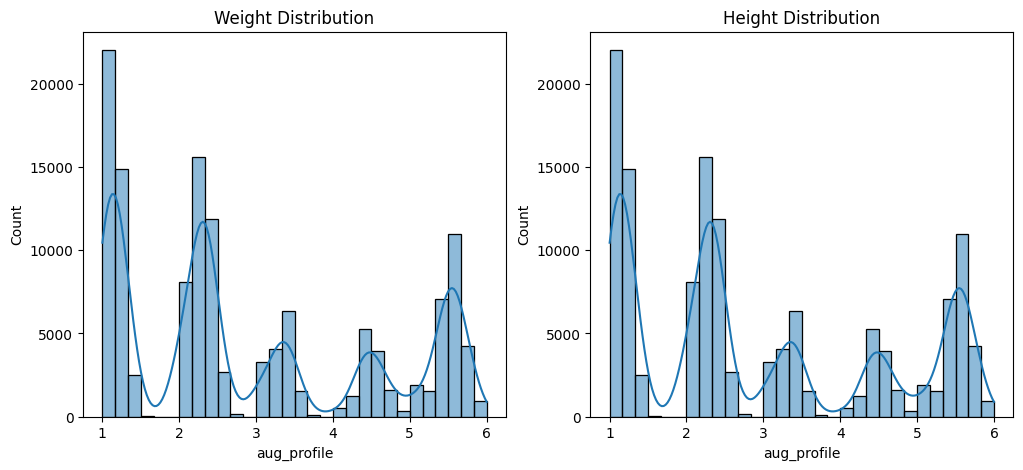

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(merged_data['aug_profile'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Weight Distribution')

sns.histplot(merged_data['aug_profile'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Height Distribution')

plt.show()

Pretty weird distribution, try multiple imputation methods

In [47]:
def evaluate_imputation_methods(model, X_train, y_train, X_val, y_val, target_col='aug_profile', random_state=None):
    """
    Evaluate different imputation methods for missing values in a specified column.
    
    Parameters:
    - model: The machine learning model to evaluate
    - X_train: Training features (DataFrame)
    - y_train: Training labels
    - X_val: Validation features (DataFrame)
    - y_val: Validation labels
    - target_col: Column with missing values to impute (default: 'aug_profile')
    - random_state: Random state for reproducibility
    
    Returns:
    - DataFrame with metrics for each imputation method
    - Best imputed training set (based on accuracy)
    """
    
    # Check if target column has missing values
    if X_train[target_col].isnull().sum() == 0:
        print(f"Column '{target_col}' has no missing values in training set.")
        return None, None
    
    # Store original data
    X_train_orig = X_train.copy()
    X_val_orig = X_val.copy()

    # Ensure indices match between X_train and y_train
    y_train = y_train.loc[X_train.index]
    y_val = y_val.loc[X_val.index]
    
    # Results storage
    results = []
    imputed_datasets = {}
    
    # 1. No imputation (drop rows with missing values)
    X_train_noimp = X_train.dropna(subset=[target_col]).copy()
    y_train_noimp = y_train[X_train[target_col].notna()]
    model_noimp = clone(model)
    model_noimp.fit(X_train_noimp, y_train_noimp)
    y_pred = model_noimp.predict(X_val.dropna(subset=[target_col]))
    y_true = y_val[X_val[target_col].notna()]
    
    if len(y_true) > 0:
        metrics = {
            'method': 'no_imputation',
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
            'recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
            'f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
            'rows_remaining': len(X_train_noimp)
        }
        results.append(metrics)
        imputed_datasets['no_imputation'] = X_train_noimp
    
    # Helper function to evaluate imputation
    def evaluate_imputation(name, X_train_imp, X_val_imp):
        model_imp = clone(model)
        model_imp.fit(X_train_imp, y_train)
        y_pred = model_imp.predict(X_val_imp)
        
        metrics = {
            'method': name,
            'accuracy': accuracy_score(y_val, y_pred),
            'precision': precision_score(y_val, y_pred, average='weighted', zero_division=0),
            'recall': recall_score(y_val, y_pred, average='weighted', zero_division=0),
            'f1': f1_score(y_val, y_pred, average='weighted', zero_division=0),
            'rows_remaining': len(X_train_imp)
        }
        print(f"\nMethod: {name}")
        print(f"→ Accuracy: {metrics['accuracy']:.4f}, Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f}, F1-score: {metrics['f1']:.4f}")
        return metrics, X_train_imp
    
    # 2. Mean imputation
    mean_val = X_train[target_col].mean()
    X_train_mean = X_train.copy()
    X_train_mean[target_col] = X_train_mean[target_col].fillna(mean_val)
    X_val_mean = X_val.copy()
    X_val_mean[target_col] = X_val_mean[target_col].fillna(mean_val)
    metrics, dataset = evaluate_imputation('mean', X_train_mean, X_val_mean)
    results.append(metrics)
    imputed_datasets['mean'] = dataset
    
    # 3. Median imputation
    median_val = X_train[target_col].median()
    X_train_median = X_train.copy()
    X_train_median[target_col] = X_train_median[target_col].fillna(median_val)
    X_val_median = X_val.copy()
    X_val_median[target_col] = X_val_median[target_col].fillna(median_val)
    metrics, dataset = evaluate_imputation('median', X_train_median, X_val_median)
    results.append(metrics)
    imputed_datasets['median'] = dataset
    
    # 4. Mode imputation
    mode_val = X_train[target_col].mode()[0]
    X_train_mode = X_train.copy()
    X_train_mode[target_col] = X_train_mode[target_col].fillna(mode_val)
    X_val_mode = X_val.copy()
    X_val_mode[target_col] = X_val_mode[target_col].fillna(mode_val)
    metrics, dataset = evaluate_imputation('mode', X_train_mode, X_val_mode)
    results.append(metrics)
    imputed_datasets['mode'] = dataset
    
    # 5. Iterative Imputer (MICE-like)
    try:
        imp_iter = IterativeImputer(max_iter=10, random_state=random_state)
        X_train_iter = X_train.copy()
        X_val_iter = X_val.copy()
        
        # Fit on training data
        imp_iter.fit(X_train_iter)
        
        # Transform both training and validation
        cols = X_train_iter.columns
        X_train_iter = pd.DataFrame(imp_iter.transform(X_train_iter), columns=cols)
        X_val_iter = pd.DataFrame(imp_iter.transform(X_val_iter), columns=cols)
        
        metrics, dataset = evaluate_imputation('iterative', X_train_iter, X_val_iter)
        results.append(metrics)
        imputed_datasets['iterative'] = dataset
    except Exception as e:
        print(f"Error with iterative imputer: {str(e)}")
    
    # 6. LOCF (Last Observation Carried Forward)
    X_train_locf = X_train.copy()
    X_train_locf[target_col] = X_train_locf[target_col].fillna(method='ffill')
    X_val_locf = X_val.copy()
    X_val_locf[target_col] = X_val_locf[target_col].fillna(X_train[target_col].ffill().iloc[-1])
    metrics, dataset = evaluate_imputation('LOCF', X_train_locf, X_val_locf)
    results.append(metrics)
    imputed_datasets['LOCF'] = dataset
    
    # 7. NOCB (Next Observation Carried Backward)
    X_train_nocb = X_train.copy()
    X_train_nocb[target_col] = X_train_nocb[target_col].fillna(method='bfill')
    X_val_nocb = X_val.copy()
    X_val_nocb[target_col] = X_val_nocb[target_col].fillna(X_train[target_col].bfill().iloc[0])
    metrics, dataset = evaluate_imputation('NOCB', X_train_nocb, X_val_nocb)
    results.append(metrics)
    imputed_datasets['NOCB'] = dataset
    
    # 8. Add missing indicator + mean imputation
    X_train_miss = X_train.copy()
    X_val_miss = X_val.copy()
    
    # Create missing indicator
    X_train_miss[f'{target_col}_missing'] = X_train_miss[target_col].isna().astype(int)
    X_val_miss[f'{target_col}_missing'] = X_val_miss[target_col].isna().astype(int)
    
    # Mean imputation
    mean_val = X_train[target_col].mean()
    X_train_miss[target_col] = X_train_miss[target_col].fillna(mean_val)
    X_val_miss[target_col] = X_val_miss[target_col].fillna(mean_val)
    
    metrics, dataset = evaluate_imputation('mean_with_missing_ind', X_train_miss, X_val_miss)
    results.append(metrics)
    imputed_datasets['mean_with_missing_ind'] = dataset
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    
    # Find best method by accuracy
    if not results_df.empty:
        best_method = results_df.loc[results_df['accuracy'].idxmax(), 'method']
        best_dataset = imputed_datasets[best_method]
        print(f"\nBest imputation method: {best_method}")
        print(results_df.loc[results_df['accuracy'].idxmax()])
    else:
        best_dataset = None
    
    return results_df, best_dataset

In [48]:
# Initialize Logistic Regression with L1 regularization (Lasso)
# Good for naive implementation -> L1 reg ('weight the important features + high dimesion handling')
# Linear model is fast

model = RandomForestClassifier(n_estimators=30,max_depth=3,class_weight='balanced',random_state=42)

results, best_dataset = evaluate_imputation_methods(
    model=model,
    X_train=X_train_data,
    y_train=y_train_data,
    X_val=X_validation_data,
    y_val=y_validation_data,
    target_col='aug_profile',
    random_state=42
)

print("\nAll results:")
print(results)


Method: mean
→ Accuracy: 0.3161, Precision: 0.4097, Recall: 0.3161, F1-score: 0.2810

Method: median
→ Accuracy: 0.3188, Precision: 0.4155, Recall: 0.3188, F1-score: 0.2827

Method: mode
→ Accuracy: 0.3129, Precision: 0.4162, Recall: 0.3129, F1-score: 0.2776

Method: iterative
→ Accuracy: 0.3143, Precision: 0.4136, Recall: 0.3143, F1-score: 0.2794


C:\Users\maria\AppData\Local\Temp\ipykernel_1712\3075607556.py:126: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_train_locf[target_col] = X_train_locf[target_col].fillna(method='ffill')



Method: LOCF
→ Accuracy: 0.3138, Precision: 0.4193, Recall: 0.3138, F1-score: 0.2792


C:\Users\maria\AppData\Local\Temp\ipykernel_1712\3075607556.py:135: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_train_nocb[target_col] = X_train_nocb[target_col].fillna(method='bfill')



Method: NOCB
→ Accuracy: 0.3146, Precision: 0.4185, Recall: 0.3146, F1-score: 0.2798

Method: mean_with_missing_ind
→ Accuracy: 0.3188, Precision: 0.3956, Recall: 0.3188, F1-score: 0.2917

Best imputation method: no_imputation
method            no_imputation
accuracy               0.324035
precision              0.409541
recall                 0.324035
f1                     0.291273
rows_remaining            93111
Name: 0, dtype: object

All results:
                  method  accuracy  precision    recall        f1  \
0          no_imputation  0.324035   0.409541  0.324035  0.291273   
1                   mean  0.316079   0.409741  0.316079  0.280969   
2                 median  0.318754   0.415532  0.318754  0.282689   
3                   mode  0.312914   0.416153  0.312914  0.277650   
4              iterative  0.314346   0.413574  0.314346  0.279395   
5                   LOCF  0.313781   0.419304  0.313781  0.279167   
6                   NOCB  0.314647   0.418542  0.314647  0.2

In [49]:
# Apply the imputer obtained at previous function
X_train_nocb = X_train_data.copy()
X_train_nocb['aug_profile'] = X_train_nocb['aug_profile'].fillna(method='bfill')

X_val_nocb = X_validation_data.copy()
X_val_nocb['aug_profile'] = X_val_nocb['aug_profile'].fillna(X_train_data['aug_profile'].bfill().iloc[0])

X_test_nocb = X_test_data.copy()
X_test_nocb['aug_profile'] = X_test_nocb['aug_profile'].fillna(X_train_data['aug_profile'].bfill().iloc[0])


C:\Users\maria\AppData\Local\Temp\ipykernel_1712\3188104546.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_train_nocb['aug_profile'] = X_train_nocb['aug_profile'].fillna(method='bfill')


In [50]:
X_train_noimp = X_train_data.dropna(subset=['aug_profile']).copy()
y_train_noimp = y_train_data[X_train_data['aug_profile'].notna()]
model_noimp = clone(model)
model_noimp.fit(X_train_noimp, y_train_noimp)
y_pred = model_noimp.predict(X_validation_data.dropna(subset=['aug_profile']))
y_true = y_validation_data[X_validation_data['aug_profile'].notna()]

C:\Users\maria\AppData\Local\Temp\ipykernel_1712\1653796040.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')


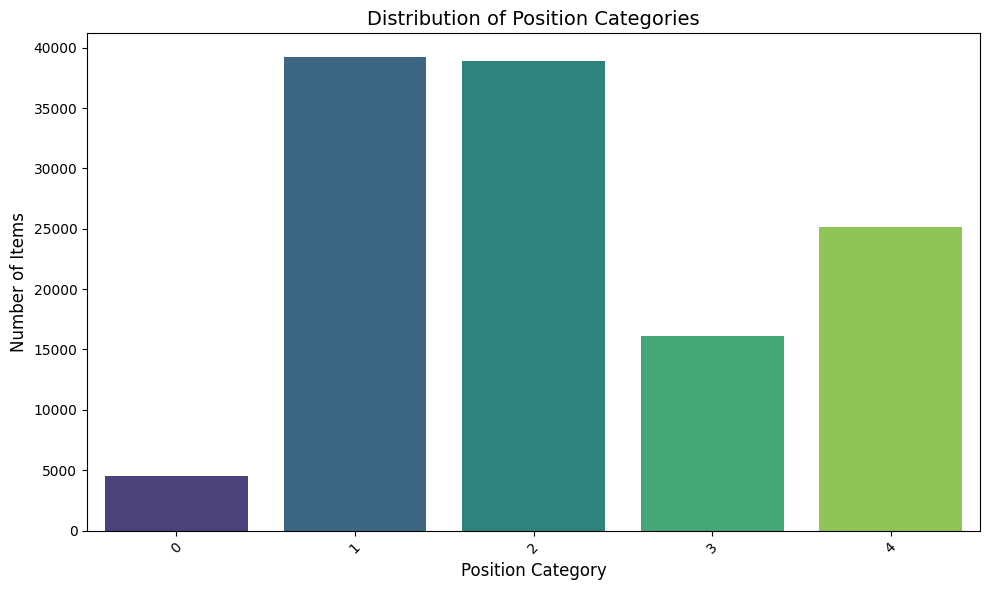

In [51]:
category_counts = y_train_data.value_counts()

plt.figure(figsize=(10, 6))

# Option A: Using Matplotlib (basic)
# category_counts.plot(kind='bar', color='skyblue', edgecolor='black')
# plt.title('Distribution of Position Categories', fontsize=14)
# plt.xlabel('Position Category', fontsize=12)
# plt.ylabel('Number of Items', fontsize=12)
# plt.xticks(rotation=45)  # Rotate labels if they're long
# plt.grid(axis='y', linestyle='--', alpha=0.7)

# Option B: Using Seaborn (more stylish)
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('Distribution of Position Categories', fontsize=14)
plt.xlabel('Position Category', fontsize=12)
plt.ylabel('Number of Items', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()  # Prevent label cutoff
plt.show()

In [ ]:
def evaluate_sampling_methods(model, X_train, y_train, X_val, y_val):
    resampling_methods = {
        "RandomOverSampler (auto)": RandomOverSampler(sampling_strategy='auto', random_state=42),
        "RandomOverSampler (not minority)": RandomOverSampler(sampling_strategy='not minority', random_state=42),
        "RandomUnderSampler": RandomUnderSampler(random_state=42),
        "SMOTE": SMOTE(random_state=42),
        "SMOTEENN": SMOTEENN(random_state=42),
        "SMOTETomek": SMOTETomek(random_state=42),
        "ADASYN": ADASYN(random_state=42)
    }

    results = {}

    for method_name, sampler in resampling_methods.items():
        try:
            print(f"\n🔄 Evaluando: **{method_name}**")

            # Resample the training data
            X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
            
            print(y_resampled.value_counts())

            # Train a new Logistic Regression model with class weights
            class_weights = {i: len(y_train) / (5 * np.bincount(y_train)[i]) for i in range(5)}
            clf = model
            clf.fit(X_resampled, y_resampled)

            # Make predictions
            y_pred = clf.predict(X_val)

            # Compute metrics
            accuracy = accuracy_score(y_val, y_pred)
            precision = precision_score(y_val, y_pred, average='weighted', zero_division=0)
            recall = recall_score(y_val, y_pred, average='weighted', zero_division=0)
            f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)

            # Store and print results
            results[method_name] = {
                "Accuracy": accuracy,
                "Precision": precision,
                "Recall": recall,
                "F1-score": f1
            }

            print(f"✅ **Resultados de {method_name}:**")
            print(f"   - Accuracy  : {accuracy:.4f}")
            print(f"   - Precision : {precision:.4f}")
            print(f"   - Recall    : {recall:.4f}")
            print(f"   - F1-score  : {f1:.4f}")

        except Exception as e:
            print(f"❌ **Error en {method_name}**: {e}")
            results[method_name] = "Error"

    return results

In [ ]:
sampling_results = evaluate_sampling_methods(
    RandomForestClassifier(n_estimators=30,max_depth=3,class_weight='balanced',random_state=42),
    X_train_noimp, y_train_noimp, X_val_nocb, y_validation_data
)
# Print all results
for method, metrics in sampling_results.items():
    print(f"\nMethod: {method}")
    print(metrics)


🔄 Evaluando: **RandomOverSampler (auto)**
position_category
1    39233
4    39233
2    39233
0    39233
3    39233
Name: count, dtype: int64
✅ **Resultados de RandomOverSampler (auto):**
   - Accuracy  : 0.8912
   - Precision : 0.9056
   - Recall    : 0.8912
   - F1-score  : 0.8861

🔄 Evaluando: **RandomOverSampler (not minority)**
position_category
1    39233
4    39233
2    39233
3    39233
0     4486
Name: count, dtype: int64
✅ **Resultados de RandomOverSampler (not minority):**
   - Accuracy  : 0.9210
   - Precision : 0.9273
   - Recall    : 0.9210
   - F1-score  : 0.9185

🔄 Evaluando: **RandomUnderSampler**
position_category
0    4486
1    4486
2    4486
3    4486
4    4486
Name: count, dtype: int64
✅ **Resultados de RandomUnderSampler:**
   - Accuracy  : 0.8384
   - Precision : 0.8466
   - Recall    : 0.8384
   - F1-score  : 0.8406

🔄 Evaluando: **SMOTE**
position_category
1    39233
4    39233
2    39233
0    39233
3    39233
Name: count, dtype: int64
✅ **Resultados de SMOTE:**

In [43]:
X_train_nocb_resampled, y_train_nocb_resampled = SMOTETomek(random_state=42).fit_resample(X_train_nocb, y_train_data)

In [44]:
rf_clf = RandomForestClassifier(n_estimators=50, max_depth=5, class_weight='balanced')
rf_clf.fit(X_train_nocb_resampled, y_train_nocb_resampled)
y_pred = rf_clf.predict(X_val_nocb)
accuracy = accuracy_score(y_validation_data, y_pred)
precision = precision_score(y_validation_data, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_validation_data, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_validation_data, y_pred, average='weighted', zero_division=0)
print(f"   - Accuracy  : {accuracy:.4f}")
print(f"   - Precision : {precision:.4f}")
print(f"   - Recall    : {recall:.4f}")
print(f"   - F1-score  : {f1:.4f}")

   - Accuracy  : 0.9888
   - Precision : 0.9889
   - Recall    : 0.9888
   - F1-score  : 0.9888


In [45]:
xgb_clf = XGBClassifier(n_estimators=10, max_depth=5, learning_rate=0.1, objective='multi:softmax')
xgb_clf.fit(X_train_nocb_resampled, y_train_nocb_resampled)
y_pred = xgb_clf.predict(X_val_nocb)
accuracy = accuracy_score(y_validation_data, y_pred)
precision = precision_score(y_validation_data, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_validation_data, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_validation_data, y_pred, average='weighted', zero_division=0)
print(f"   - Accuracy  : {accuracy:.4f}")
print(f"   - Precision : {precision:.4f}")
print(f"   - Recall    : {recall:.4f}")
print(f"   - F1-score  : {f1:.4f}")

   - Accuracy  : 1.0000
   - Precision : 1.0000
   - Recall    : 1.0000
   - F1-score  : 1.0000


In [46]:
ab_clf = AdaBoostClassifier(n_estimators=50, random_state=42)
ab_clf.fit(X_train_nocb_resampled, y_train_nocb_resampled)
y_pred = ab_clf.predict(X_val_nocb)
accuracy = accuracy_score(y_validation_data, y_pred)
precision = precision_score(y_validation_data, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_validation_data, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_validation_data, y_pred, average='weighted', zero_division=0)
print(f"   - Accuracy  : {accuracy:.4f}")
print(f"   - Precision : {precision:.4f}")
print(f"   - Recall    : {recall:.4f}")
print(f"   - F1-score  : {f1:.4f}")

   - Accuracy  : 1.0000
   - Precision : 1.0000
   - Recall    : 1.0000
   - F1-score  : 1.0000


In [47]:
clf1 = LogisticRegression(random_state=42)
clf2 = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
clf3 = AdaBoostClassifier(n_estimators=50, random_state=42)
vc_clf = VotingClassifier(estimators=[('lr',clf1),('rf',clf2),('ab',clf3)])
vc_clf.fit(X_train_nocb_resampled, y_train_nocb_resampled)
y_pred = vc_clf.predict(X_val_nocb)
accuracy = accuracy_score(y_validation_data, y_pred)
precision = precision_score(y_validation_data, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_validation_data, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_validation_data, y_pred, average='weighted', zero_division=0)
print(f"   - Accuracy  : {accuracy:.4f}")
print(f"   - Precision : {precision:.4f}")
print(f"   - Recall    : {recall:.4f}")
print(f"   - F1-score  : {f1:.4f}")

/home/unai/Documents/Uni/Año4/Deusto/AML/AMLEnv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


   - Accuracy  : 0.9054
   - Precision : 0.9223
   - Recall    : 0.9054
   - F1-score  : 0.9061


In [48]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('ab', AdaBoostClassifier(n_estimators=50, random_state=42))
]
stk_clf = StackingClassifier(
    estimators=estimators, final_estimator=LogisticRegression()
)
stk_clf.fit(X_train_nocb_resampled, y_train_nocb_resampled)
y_pred = stk_clf.predict(X_val_nocb)
accuracy = accuracy_score(y_validation_data, y_pred)
precision = precision_score(y_validation_data, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_validation_data, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_validation_data, y_pred, average='weighted', zero_division=0)
print(f"   - Accuracy  : {accuracy:.4f}")
print(f"   - Precision : {precision:.4f}")
print(f"   - Recall    : {recall:.4f}")
print(f"   - F1-score  : {f1:.4f}")

   - Accuracy  : 1.0000
   - Precision : 1.0000
   - Recall    : 1.0000
   - F1-score  : 1.0000


In [62]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 2, 200)
    max_depth = trial.suggest_int('max_depth', 1, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 32)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 32)

    model = RandomForestClassifier(n_estimators=n_estimators,
                                   max_depth=max_depth,
                                   min_samples_split=min_samples_split,
                                   min_samples_leaf=min_samples_leaf)
    
    model.fit(X_train_nocb_resampled,y_train_nocb_resampled)
    y_pred = model.predict(X_val_nocb)
    
    score = f1_score(y_pred=y_pred, y_true=y_validation_data, average='weighted', zero_division=0)

    return score

In [64]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

[I 2025-03-31 10:27:19,186] A new study created in memory with name: no-name-39bd00d5-9a02-44fa-a9e7-25f36fdb8591
[I 2025-03-31 10:27:34,857] Trial 0 finished with value: 0.8500880640620493 and parameters: {'n_estimators': 129, 'max_depth': 4, 'min_samples_split': 22, 'min_samples_leaf': 26}. Best is trial 0 with value: 0.8500880640620493.
[I 2025-03-31 10:27:59,261] Trial 1 finished with value: 0.9998869802063666 and parameters: {'n_estimators': 101, 'max_depth': 11, 'min_samples_split': 23, 'min_samples_leaf': 11}. Best is trial 1 with value: 0.9998869802063666.
[I 2025-03-31 10:28:19,409] Trial 2 finished with value: 0.8978754516230655 and parameters: {'n_estimators': 135, 'max_depth': 5, 'min_samples_split': 28, 'min_samples_leaf': 16}. Best is trial 1 with value: 0.9998869802063666.
[I 2025-03-31 10:28:31,719] Trial 3 finished with value: 0.9998869802063666 and parameters: {'n_estimators': 49, 'max_depth': 14, 'min_samples_split': 32, 'min_samples_leaf': 30}. Best is trial 1 with 

In [65]:
study.best_params

{'n_estimators': 171,
 'max_depth': 11,
 'min_samples_split': 24,
 'min_samples_leaf': 20}

In [ ]:
#Model with the best parameters and test set 
model = RandomForestClassifier(**study.best_params)
model.fit(X_train_nocb_resampled,y_train_nocb_resampled)
y_pred = model.predict(X_test_nocb)
accuracy = accuracy_score(y_test_data, y_pred)
precision = precision_score(y_test_data, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test_data, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test_data, y_pred, average='weighted', zero_division=0)
print(f"   - Accuracy  : {accuracy:.4f}")
print(f"   - Precision : {precision:.4f}")
print(f"   - Recall    : {recall:.4f}")
print(f"   - F1-score  : {f1:.4f}")

   - Accuracy  : 0.9998
   - Precision : 0.9998
   - Recall    : 0.9998
   - F1-score  : 0.9998


In [74]:
xgb_clf = XGBClassifier(n_estimators=10, max_depth=5, learning_rate=0.1, objective='multi:softmax')
xgb_clf.fit(X_train_nocb_resampled,y_train_nocb_resampled)
y_pred = xgb_clf.predict(X_test_nocb)
accuracy = accuracy_score(y_test_data, y_pred)
precision = precision_score(y_test_data, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test_data, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test_data, y_pred, average='weighted', zero_division=0)
print(f"   - Accuracy  : {accuracy:.4f}")
print(f"   - Precision : {precision:.4f}")
print(f"   - Recall    : {recall:.4f}")
print(f"   - F1-score  : {f1:.4f}")

   - Accuracy  : 1.0000
   - Precision : 1.0000
   - Recall    : 1.0000
   - F1-score  : 1.0000
